# Лабораторная работа №8
## *Определение частот трезвучия в аудиосигнале*

по курсу Цифровая обработка сигналов

**направление:** Речевые технологии и машинное обучение  
**преподаватель:** Рыбин Сергей Витальевич  
**выполнил:** Янкин Иван Ю.  
**группа:** М4121

## Импорт

In [11]:
import numpy as np
import scipy.io.wavfile as wav
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from typing import Tuple, List, Optional
from IPython.display import Audio, display

In [2]:
def load_audio(file_path: str):
    sr, signal = wav.read(file_path)
    return signal, sr

## Вспомогательные функции

In [3]:
#@title Функция вычисления логарифмического амплитудного спектра
def compute_log_spectrum(signal: np.ndarray, sr: int, n_fft: int = 8192):
    # Разбиваем сигнал на перекрывающиеся сегменты
    hop_length = n_fft // 2
    n_segments = (len(signal) - n_fft) // hop_length + 1

    spectra = []
    for i in range(n_segments):
        segment = signal[i*hop_length:i*hop_length + n_fft]
        windowed = segment * np.hanning(n_fft)
        spectrum = np.abs(fft(windowed, n_fft))
        spectra.append(spectrum[:n_fft//2])  # только положительные частоты

    avg_spectrum = np.mean(spectra, axis=0)
    log_spectrum = 20 * np.log10(avg_spectrum + 1e-10)  # dB
    freqs = fftfreq(n_fft, 1/sr)[:n_fft//2]

    return freqs, log_spectrum

In [4]:
#@title Функция поиска основных пиков
def find_main_peaks(freqs, spectrum, min_distance=50, prominence=10):
    peaks, properties = find_peaks(spectrum, distance=min_distance, prominence=prominence)

    peak_freqs = freqs[peaks]
    peak_amps = spectrum[peaks]

    # перебираем все комбинации из 3 пиков
    candidate_triads = []

    for i in range(len(peaks)):
        for j in range(i+1, len(peaks)):
            for k in range(j+1, len(peaks)):
                f1, f2, f3 = sorted([peak_freqs[i], peak_freqs[j], peak_freqs[k]])
                a1, a2, a3 = [peak_amps[idx] for idx in [i, j, k]]

                # проверяем муз. интервалы
                interval_12 = 12 * np.log2(f2 / f1)  # P1-P2 в полутонах
                interval_13 = 12 * np.log2(f3 / f1)  # P1-P3 в полутонах

                # Допуски: ±0.5 полутона
                if not (2.5 <= interval_12 <= 4.5):  # должна быть 3 или 4 полутона
                    continue
                if not (6.5 <= interval_13 <= 7.5):  # квинта = 7 полутонов
                    continue

                # проверяем, что f3 не гармоника f1 или f2
                if abs(f3 - 2*f1) < 10 or abs(f3 - 2*f2) < 10:  # допуск 10 Гц
                    continue

                quality = a1 + a2 + a3  # сумма амплитуд
                candidate_triads.append((quality, f1, f2, f3))

    # выбираем комбинацию с максимальной суммой амплитуд
    best_triad = max(candidate_triads, key=lambda x: x[0])
    freqs_result = np.array([best_triad[1], best_triad[2], best_triad[3]])

    # Найдем амплитуды для этих частот
    amps_result = []
    for f in freqs_result:
        idx = np.argmin(np.abs(peak_freqs - f))
        amps_result.append(peak_amps[idx])

    return freqs_result, np.array(amps_result)

In [5]:
#@title Функция проверки обертонов
def verify_overtones(freqs: np.ndarray, spectrum: np.ndarray,
                     candidate_freqs: np.ndarray, tolerance: float = 2):
    for f in candidate_freqs:
      for i in range(2):
        # Проверяем вторую гармонику
        harmonic_2f = i * 2 * f
        idx = np.argmin(np.abs(freqs - harmonic_2f))
        if np.abs(freqs[idx] - harmonic_2f) > tolerance:
            return False
        # Проверяем третью гармонику
        harmonic_3f = i * 3 * f
        idx = np.argmin(np.abs(freqs - harmonic_3f))
        if np.abs(freqs[idx] - harmonic_3f) > tolerance:
            return False
    return True

In [6]:
#@title Функция определения тональности
def identify_tonality(frequencies: np.ndarray, base_freq: float = 130.82):
    note_names = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

    # вычисляем сдвиги в полутонах
    semitone_shifts = []
    for f in frequencies:
        shift = 12 * np.log2(f / base_freq)
        semitone_shifts.append(round(shift))

    semitone_shifts.sort()
    base_shift = semitone_shifts[0]
    normalized = tuple([s - base_shift for s in semitone_shifts])

    # Определяем тип трезвучия по интервалам
    # Мажор: (0, 4, 7) | Минор: (0, 3, 7)
    if normalized == (0, 4, 7):
        tonality_type = "major"
    elif normalized == (0, 3, 7):
        tonality_type = "minor"
    else:
        return "извините, я такого не знаю :С"

    # Определяем тональность
    # Берем по модулю 12 для работы в пределах одной октавы
    note_index = base_shift % 12
    note = note_names[note_index]

    return f"{note} {tonality_type}"

## Основной анализ

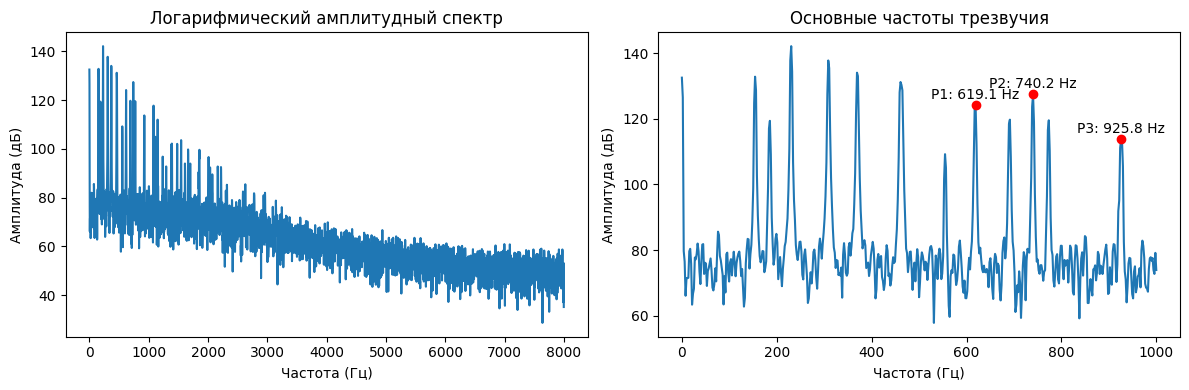

In [14]:
# 1. Загрузка аудио
audio_path = 'DTLab16.wav'
signal, sr = load_audio(audio_path)

# 2. Вычисление спектра
freqs, log_spectrum = compute_log_spectrum(signal, sr, n_fft=8192)

# 3. Поиск основных пиков
main_freqs, main_amps = find_main_peaks(freqs, log_spectrum, min_distance=50)

# 4. Проверка обертонов
overtones_ok = verify_overtones(freqs, log_spectrum, main_freqs, tolerance=2)

# 5. Определение тональности
tonality = identify_tonality(main_freqs)

# 6. Визуализация (опционально)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Полный спектр
axs[0].plot(freqs, log_spectrum)
axs[0].set_xlabel('Частота (Гц)')
axs[0].set_ylabel('Амплитуда (дБ)')
axs[0].set_title('Логарифмический амплитудный спектр')

# Увеличенная область низких частот
max_freq_plot = 1000
idx_limit = np.argmax(freqs > max_freq_plot)
axs[1].plot(freqs[:idx_limit], log_spectrum[:idx_limit])
axs[1].scatter(main_freqs, main_amps, color='red', zorder=5)
for i, (f, a) in enumerate(zip(main_freqs, main_amps), 1):
    axs[1].text(f, a + 2, f'P{i}: {f:.1f} Hz', ha='center')
axs[1].set_xlabel('Частота (Гц)')
axs[1].set_ylabel('Амплитуда (дБ)')
axs[1].set_title(f'Основные частоты трезвучия')

plt.tight_layout()
plt.show()

# результаты
results = {
    'sample_rate': sr,
    'signal_duration': len(signal) / sr,
    'frequencies': main_freqs.tolist(),
    'amplitudes': main_amps.tolist(),
    'overtones_verified': overtones_ok,
    'tonality': tonality,
    'notes': ['P1 (основной)', 'P2 (терцовый)', 'P3 (квинтовый)']
}

In [15]:
print(f"Частота дискретизации: {results['sample_rate']} Гц")
print(f"Длительность сигнала: {results['signal_duration']:.2f} с")
print("\nНайденные частоты:")
for note, freq, amp in zip(results['notes'], results['frequencies'], results['amplitudes']):
  print(f"~ {note}: {freq:.2f} Гц (амплитуда: {amp:.2f} дБ)")
print(f"\nПроверка обертонов: {results['overtones_verified']}")
print(f"Тональность: {results['tonality']}")

Частота дискретизации: 16000 Гц
Длительность сигнала: 5.00 с

Найденные частоты:
~ P1 (основной): 619.14 Гц (амплитуда: 124.14 дБ)
~ P2 (терцовый): 740.23 Гц (амплитуда: 127.41 дБ)
~ P3 (квинтовый): 925.78 Гц (амплитуда: 113.71 дБ)

Проверка обертонов: True
Тональность: D# minor


## Проверка

In [20]:
sr = results['sample_rate']
t = np.linspace(0, 2, int(2*sr), False)

# Ноты аккорда D#m (D#, F#, A#)
freqs = [311.13, 369.99, 466.16]  # Гц
signal_orig = sum(np.sin(2 * np.pi * f * t) for f in freqs)

display(Audio(signal_orig, rate=sr, autoplay=True))
display(Audio(signal, rate=sr, autoplay=True))